# Customer Review Sentiment Analysis — Exploration & Experiments

This notebook is the **lab notebook** for the project. It shows the work behind the
decisions that are baked into `src/`:

1. Loading and exploring the data
2. What text cleaning actually does
3. The train/test split, and why it comes first
4. TF-IDF: what the numbers mean, and how sparse the matrix is
5. **The experiments** that chose `min_df`, `C`, the n-gram range and `sublinear_tf`
6. Training both models and evaluating them
7. Reading the model's weights — what did it actually learn?
8. Error analysis: looking at the reviews it got wrong

Every number below is computed when you run the notebook. Nothing is typed in by hand.

**Before running:** from the project root, `python -m src.download_data`

## 0. Setup

In [1]:
import sys
from pathlib import Path

# Make `src` importable when the notebook runs from the notebooks/ folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config, evaluate, features, preprocessing

# Draw charts inside the notebook. (src.evaluate imports pyplot but does not
# force a backend, so this stays in charge.)
%matplotlib inline

pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.figsize"] = (7, 4)
print("Project root:", PROJECT_ROOT)

Project root: F:\PERSONAL\ML Projects\Customer Review Sentiment Analysis


## 1. Load and explore the data

`load_dataset()` does the row-level cleaning: it normalises the labels, drops missing
and blank reviews, drops duplicates, and adds a `clean_review` column.

In [2]:
df = preprocessing.load_dataset()
df.head()

Loaded 3000 rows from reviews.csv
Usable rows after cleaning: 2982 (removed 18)
  Negative: 1492 (50.0%)
  Positive: 1490 (50.0%)


,review,label,source,clean_review
0,So there is no way for me to plug it in here in the US unless I go by a converter.,0,amazon,so there is no way for me to plug it in here in the us unless i go by a converter
1,"Good case, Excellent value.",1,amazon,good case excellent value
2,Great for the jawbone.,1,amazon,great for the jawbone
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,0,amazon,tied to charger for conversations lasting more than 45 minutes major problems
4,The mic is great.,1,amazon,the mic is great


In [3]:
print("Shape:", df.shape)
print("\nColumns and types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum())

Shape: (2982, 4)

Columns and types:
review            str
label           int64
source            str
clean_review      str
dtype: object

Missing values per column:
review          0
label           0
source          0
clean_review    0
dtype: int64


### Class balance

This is the first thing to check, because it decides whether **accuracy** is a fair
headline metric. On a balanced dataset the coin-flip baseline is 50%. On a 95/5
dataset, a model that always answers with the majority class scores 95% while being
useless.

Negative    1492
Positive    1490
Name: count, dtype: int64

Balance: 50.0% positive


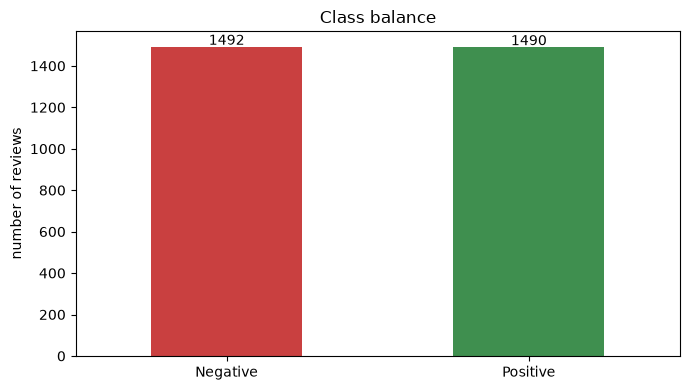

In [4]:
counts = df[config.LABEL_COLUMN].value_counts().sort_index()
counts.index = [config.LABEL_NAMES[i] for i in counts.index]
print(counts)
print(f"\nBalance: {counts.iloc[1] / len(df):.1%} positive")

ax = counts.plot(kind="bar", color=["#c94040", "#3f8f4f"], rot=0)
ax.set_title("Class balance")
ax.set_ylabel("number of reviews")
for i, v in enumerate(counts):
    ax.text(i, v + 10, str(v), ha="center")
plt.tight_layout()
plt.show()

### Where do the reviews come from?

In [5]:
if "source" in df.columns:
    print(df.groupby("source")[config.LABEL_COLUMN].agg(
        rows="size", positive_share="mean").round(3))

        rows  positive_share
source                      
amazon   990           0.498
imdb     996           0.500
yelp     996           0.501


### How long are the reviews?

This matters a lot for interpreting the results later: these are single **sentences**,
not full reviews. It explains both why the model does reasonably well (short, clear,
one opinion each) and why it would struggle on a real 200-word review that mixes
praise and complaints.

count    2982.00
mean       12.18
std         8.11
min         1.00
25%         6.00
50%        11.00
75%        17.00
max        74.00
Name: clean_review, dtype: float64


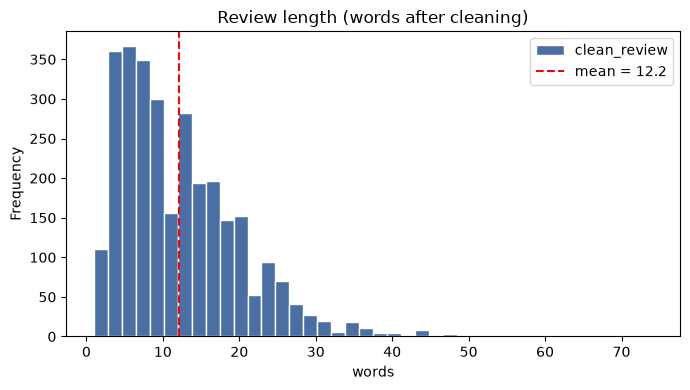

In [6]:
word_counts = df["clean_review"].str.split().str.len()
print(word_counts.describe().round(2))

ax = word_counts.plot(kind="hist", bins=40, color="#4a6fa5", edgecolor="white")
ax.set_title("Review length (words after cleaning)")
ax.set_xlabel("words")
ax.axvline(word_counts.mean(), color="red", linestyle="--",
           label=f"mean = {word_counts.mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# The shortest and longest reviews -- a quick sanity check that cleaning did not
# mangle anything.
print("SHORTEST:")
for text in df.loc[word_counts.nsmallest(3).index, config.TEXT_COLUMN]:
    print("  ", repr(text))
print("\nLONGEST:")
print("  ", repr(df.loc[word_counts.idxmax(), config.TEXT_COLUMN][:200]))

SHORTEST:
   'Incredible!.'
   'Disappointed!.'
   'disappointing.'

LONGEST:
   "This is a masterful piece of film-making, with many themes simmering and occasionally boiling over in this warts and all study of the poet's bohemian, self-indulgent wartime years that span the aerial"


### Which words are most common in each class?

A quick look before any modelling. If the top words per class already look like
sentiment words, the problem is learnable with a bag-of-words model.

In [8]:
from collections import Counter

def top_words(subset, n=12):
    words = Counter(" ".join(subset["clean_review"]).split())
    return pd.Series(dict(words.most_common(n)))

positive_top = top_words(df[df[config.LABEL_COLUMN] == 1])
negative_top = top_words(df[df[config.LABEL_COLUMN] == 0])

comparison = pd.DataFrame({"positive reviews": positive_top,
                           "negative reviews": negative_top})
print(comparison.fillna("-"))

      positive reviews negative reviews
a                467.0            420.0
and              674.0            464.0
great            195.0                -
i                482.0            552.0
in               206.0                -
is               416.0            336.0
it               382.0            407.0
not                  -            247.0
of               310.0            314.0
t                    -            214.0
the              995.0            956.0
this             326.0            312.0
to               307.0            362.0
was              257.0            313.0


Notice how much overlap there is — `the`, `and`, `a`, `is` dominate both columns.
Raw counts are mostly measuring grammar, not sentiment. **This is exactly the problem
IDF solves**, by down-weighting words that appear everywhere.

## 2. What does the text cleaning do?

`clean_text()` is deliberately light. Watch what it keeps.

In [9]:
examples = [
    "GREAT phone!!! Highly recommended.",
    "Terrible.  Visit http://refund-me.com <br /> for my review.",
    "Only 2 stars, and it's NOT good at all...",
    "Caf\u00e9 food was      lovely!",
]
for text in examples:
    print(f"before: {text!r}")
    print(f"after : {preprocessing.clean_text(text)!r}\n")

before: 'GREAT phone!!! Highly recommended.'
after : 'great phone highly recommended'

before: 'Terrible.  Visit http://refund-me.com <br /> for my review.'
after : 'terrible visit for my review'

before: "Only 2 stars, and it's NOT good at all..."
after : 'only 2 stars and it s not good at all'

before: 'Café food was      lovely!'
after : 'caf food was lovely'



Two things to notice:

- **`not` survives.** We do not remove stopwords, because `"not good"` minus `"not"`
  is `"good"` — the opposite meaning.
- **Digits survive.** `"2 stars"` carries real information.

Here is the cost of getting that wrong. The opt-in stopword helper keeps negations,
but a *typical* stopword list would not:

In [10]:
sentence = "the product is not good and i do not like it"
print("original          :", sentence)
print("our safe stopwords:", preprocessing.remove_stopwords(sentence))

# A typical off-the-shelf stopword list DOES include "not".
typical = preprocessing.SAFE_STOPWORDS | {"not", "no", "never"}
print("typical list      :", preprocessing.remove_stopwords(sentence, typical))
print("\n-> the last line now reads as POSITIVE. That is why we keep negations.")

original          : the product is not good and i do not like it
our safe stopwords: product not good not like
typical list      : product good like

-> the last line now reads as POSITIVE. That is why we keep negations.


## 3. Train/test split — before anything else

The split happens **before** the vectorizer is fitted. This is the single most
important rule in the project: if TF-IDF is fitted on all the data, the vocabulary and
the IDF weights are computed using test reviews, and the test score becomes
optimistic. That is **data leakage**.

In [11]:
from sklearn.model_selection import train_test_split

x_train_text, x_test_text, y_train, y_test = train_test_split(
    df["clean_review"],
    df[config.LABEL_COLUMN],
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE,
    stratify=df[config.LABEL_COLUMN],     # keep the class ratio in both halves
)

print(f"train: {len(x_train_text)} reviews  ({y_train.mean():.1%} positive)")
print(f"test : {len(x_test_text)} reviews  ({y_test.mean():.1%} positive)")
print("\n-> stratification kept the positive share nearly identical in both halves.")

train: 2385 reviews  (50.0% positive)
test : 597 reviews  (49.9% positive)

-> stratification kept the positive share nearly identical in both halves.


## 4. TF-IDF: text to numbers

`fit_transform` on train (learns the vocabulary + IDF), `transform` on test (reuses
what it learned).

In [12]:
vectorizer = features.build_vectorizer()
x_train = features.fit_transform_train(vectorizer, x_train_text)
x_test = features.transform_test(vectorizer, x_test_text)

print(f"train matrix : {x_train.shape[0]} reviews x {x_train.shape[1]} features")
print(f"test matrix  : {x_test.shape[0]} reviews x {x_test.shape[1]} features")
print(f"vocabulary   : {len(vectorizer.vocabulary_):,} terms")
print(f"\nnon-zero cells : {x_train.nnz:,}")
print(f"total cells    : {x_train.shape[0] * x_train.shape[1]:,}")
print(f"density        : {x_train.nnz / (x_train.shape[0] * x_train.shape[1]):.4%}")
print(f"\naverage non-zero features per review: {x_train.nnz / x_train.shape[0]:.1f}")
print("-> 99.9% of the matrix is zeros, which is why it is stored sparsely.")

train matrix : 2385 reviews x 20000 features
test matrix  : 597 reviews x 20000 features
vocabulary   : 20,000 terms

non-zero cells : 48,425
total cells    : 47,700,000
density        : 0.1015%

average non-zero features per review: 20.3
-> 99.9% of the matrix is zeros, which is why it is stored sparsely.


### Unigrams and bigrams both made it into the vocabulary

In [13]:
vocab = vectorizer.get_feature_names_out()
unigrams = [t for t in vocab if " " not in t]
bigrams = [t for t in vocab if " " in t]
print(f"unigrams: {len(unigrams):,}")
print(f"bigrams : {len(bigrams):,}")

# The negation bigrams are the whole reason for ngram_range=(1, 2).
interesting = [t for t in bigrams if t.startswith(("not ", "never ", "too "))]
print(f"\nnegation-style bigrams found: {len(interesting)}")
print("examples:", interesting[:12])

unigrams: 4,375
bigrams : 15,625

negation-style bigrams found: 184
examples: ['never been', 'never brought', 'never ceases', 'never come', 'never condescends', 'never empty', 'never ever', 'never experienced', 'never forget', 'never get', 'never go', 'never going']


### IDF in action

IDF is high for rare words and low for common ones. It is *automatic, data-driven
stopword removal* — we never wrote a list of boring words.

In [14]:
idf = pd.Series(vectorizer.idf_, index=vocab).sort_values()
print("LOWEST IDF (appear almost everywhere -> nearly worthless):")
print(idf.head(10).round(3).to_string())
print("\nHIGHEST IDF (appear in one review -> highly distinctive):")
print(idf.tail(5).round(3).to_string())

LOWEST IDF (appear almost everywhere -> nearly worthless):
the     1.805
and     2.148
it      2.467
is      2.524
this    2.616
to      2.659
of      2.702
was     2.786
in      3.060
for     3.260

HIGHEST IDF (appear in one review -> highly distinctive):
yukon gold           8.084
your laptop          8.084
afraid to            8.084
afraid of            8.084
affordable prices    8.084


In [15]:
# TF-IDF values for one sentence, computed by the fitted vectorizer.
sentence = preprocessing.clean_text("the food was not good")
row = vectorizer.transform([sentence])

values = pd.DataFrame(
    [(vocab[c], row[0, c], vectorizer.idf_[c]) for c in row.indices],
    columns=["term", "tf_idf", "idf"],
).sort_values("tf_idf", ascending=False)

print(f"Sentence: {sentence!r}\n")
print(values.round(4).to_string(index=False))
print("\n-> with plain word counts every term here would score 1.")
print("-> TF-IDF ranks 'not good' top and 'the' bottom, with no rules written by us.")

Sentence: 'the food was not good'

    term  tf_idf    idf
not good  0.4599 6.2124
 was not  0.4401 5.9442
food was  0.4058 5.4815
the food  0.3767 5.0885
    food  0.3127 4.2235
    good  0.2625 3.5463
     not  0.2472 3.3393
     was  0.2063 2.7859
     the  0.1336 1.8048

-> with plain word counts every term here would score 1.
-> TF-IDF ranks 'not good' top and 'the' bottom, with no rules written by us.


## 5. The experiments

This is where the parameters in `src/features.py` and `src/train.py` come from.

**Every score below is 5-fold cross-validation on the TRAINING SET ONLY.** The test
set is not touched until section 6. Tuning on the test set would make it no longer
unseen — that is test-set leakage.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

folds = StratifiedKFold(n_splits=config.CV_FOLDS, shuffle=True,
                        random_state=config.RANDOM_STATE)

def cv_score(vec, clf):
    """Cross-validate a (vectorizer, classifier) pair on the training data.

    Using a Pipeline matters: it refits the vectorizer inside every fold, so the
    fold's validation slice never influences its own IDF weights. Doing this by
    hand is where people accidentally leak.
    """
    scores = cross_val_score(make_pipeline(vec, clf), x_train_text, y_train,
                             cv=folds, scoring="accuracy")
    return scores.mean(), scores.std()

def tfidf(**kwargs):
    params = dict(ngram_range=(1, 2), min_df=1, max_features=20_000,
                  strip_accents="unicode", lowercase=False)
    params.update(kwargs)
    return TfidfVectorizer(**params)

def logreg(C=10.0):
    return LogisticRegression(solver="liblinear", C=C, max_iter=1000,
                              random_state=config.RANDOM_STATE)

### Experiment 1 — how strong should regularisation be? (`C`)

    C  cv_accuracy    std
  0.1       0.7895 0.0056
  1.0       0.8101 0.0091
  2.0       0.8214 0.0118
  5.0       0.8306 0.0049
 10.0       0.8386 0.0055
 20.0       0.8423 0.0087
 50.0       0.8390 0.0067
100.0       0.8403 0.0061


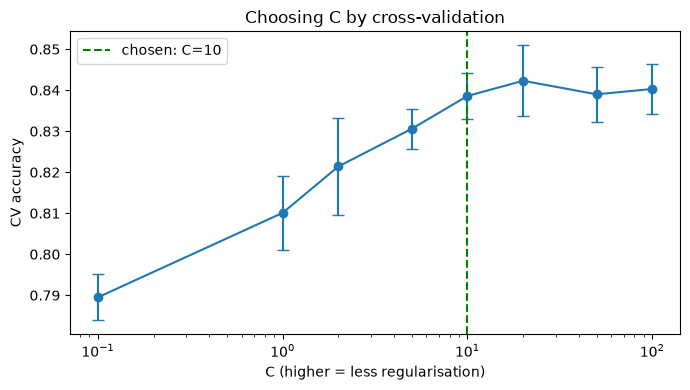

In [17]:
rows = []
for C in [0.1, 1, 2, 5, 10, 20, 50, 100]:
    mean, std = cv_score(tfidf(), logreg(C))
    rows.append({"C": C, "cv_accuracy": round(mean, 4), "std": round(std, 4)})

results_c = pd.DataFrame(rows)
print(results_c.to_string(index=False))

ax = plt.subplot()
ax.errorbar(results_c["C"], results_c["cv_accuracy"], yerr=results_c["std"],
            marker="o", capsize=4)
ax.set_xscale("log")
ax.set_xlabel("C (higher = less regularisation)")
ax.set_ylabel("CV accuracy")
ax.set_title("Choosing C by cross-validation")
ax.axvline(10, color="green", linestyle="--", label="chosen: C=10")
ax.legend()
plt.tight_layout()
plt.show()

**Reading the chart:** the low-`C` end is **underfitting** — the penalty is so strong
it crushes the weights and the model cannot use the evidence. The curve then rises and
flattens. Everything from `C=10` upwards sits inside one standard deviation of the
best score, so we pick the **smallest `C` on the plateau**: the same accuracy with more
regularisation and a simpler model.

### Experiment 2 — should rare words be dropped? (`min_df`)

In [18]:
rows = []
for min_df in [1, 2, 3, 5]:
    vec = tfidf(min_df=min_df)
    mean, std = cv_score(vec, logreg())
    vec.fit(x_train_text)
    rows.append({"min_df": min_df, "vocabulary": len(vec.vocabulary_),
                 "cv_accuracy": round(mean, 4), "std": round(std, 4)})

print(pd.DataFrame(rows).to_string(index=False))

 min_df  vocabulary  cv_accuracy    std
      1       20000       0.8386 0.0055
      2        4512       0.8302 0.0087
      3        2347       0.8184 0.0091
      5        1174       0.7933 0.0160


**This is the result that goes against the textbook.** The usual advice is `min_df=2`
or higher, on the grounds that a word appearing in only one document is probably a
typo. That is true on a *large* corpus. Our training set is ~2,400 short sentences,
where a once-seen word is quite often a real sentiment word like `flawless` or
`refund` — there simply is not enough text for it to appear twice.

So we keep `min_df=1`, and note that on a 500,000-review dataset this experiment
should be re-run, because the answer would very likely flip.

### Experiment 3 — do bigrams help? (`ngram_range`)

In [19]:
rows = []
for ngram in [(1, 1), (1, 2), (1, 3)]:
    vec = tfidf(ngram_range=ngram)
    mean, std = cv_score(vec, logreg())
    vec.fit(x_train_text)
    rows.append({"ngram_range": str(ngram), "vocabulary": len(vec.vocabulary_),
                 "cv_accuracy": round(mean, 4), "std": round(std, 4)})

print(pd.DataFrame(rows).to_string(index=False))

ngram_range  vocabulary  cv_accuracy    std
     (1, 1)        4533       0.8327 0.0177
     (1, 2)       20000       0.8386 0.0055
     (1, 3)       20000       0.8239 0.0070


Bigrams help. Trigrams add a lot of features for no gain — longer phrases are rarer,
so most appear once or twice, which is not enough to learn a reliable weight from.
`(1, 2)` is the sweet spot.

### Experiment 4 — `sublinear_tf`, and Naive Bayes smoothing

In [20]:
rows = []
for label, vec, clf in [
    ("LogReg, sublinear_tf=False", tfidf(sublinear_tf=False), logreg()),
    ("LogReg, sublinear_tf=True", tfidf(sublinear_tf=True), logreg()),
    ("NaiveBayes, alpha=1.0", tfidf(), MultinomialNB(alpha=1.0)),
    ("NaiveBayes, alpha=0.3", tfidf(), MultinomialNB(alpha=0.3)),
    ("NaiveBayes, alpha=0.1", tfidf(), MultinomialNB(alpha=0.1)),
]:
    mean, std = cv_score(vec, clf)
    rows.append({"setup": label, "cv_accuracy": round(mean, 4),
                 "std": round(std, 4)})

print(pd.DataFrame(rows).to_string(index=False))

                     setup  cv_accuracy    std
LogReg, sublinear_tf=False       0.8386 0.0055
 LogReg, sublinear_tf=True       0.8356 0.0051
     NaiveBayes, alpha=1.0       0.8356 0.0102
     NaiveBayes, alpha=0.3       0.8394 0.0131
     NaiveBayes, alpha=0.1       0.8289 0.0105


`sublinear_tf` replaces a raw count with `1 + log(count)` to dampen repeated words.
It makes no useful difference here, and that makes sense: these are single sentences,
so almost no word repeats inside one review — there is nothing to dampen. We leave it
off rather than carry a parameter that does nothing.

The Naive Bayes smoothing results are close together and the differences are inside
the standard deviation, so we keep the default `alpha=1.0`.

## 6. Train the final models and evaluate on the test set

Now — and only now — we touch the test set.

In [21]:
models = {
    "Logistic Regression": logreg(C=10.0),
    "Multinomial Naive Bayes": MultinomialNB(alpha=1.0),
}

summary = []
predictions = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1]
    predictions[name] = y_pred

    metrics = evaluate.compute_metrics(y_test, y_pred, y_proba)
    summary.append({
        "model": name,
        "train_acc": round(model.score(x_train, y_train), 4),
        "test_acc": round(metrics["accuracy"], 4),
        "precision": round(metrics["precision_positive"], 4),
        "recall": round(metrics["recall_positive"], 4),
        "f1_macro": round(metrics["f1_macro"], 4),
        "roc_auc": round(metrics["roc_auc"], 4),
    })

pd.DataFrame(summary).set_index("model")

,train_acc,test_acc,precision,recall,f1_macro,roc_auc
model,,,,,,
Logistic Regression,1.0000,0.8208,0.8215,0.8188,0.8208,0.8952
Multinomial Naive Bayes,0.9941,0.8107,0.8073,0.8154,0.8107,0.8939


In [22]:
evaluate.print_report("Logistic Regression", y_test, predictions["Logistic Regression"])


--- Logistic Regression ---
              precision    recall  f1-score   support

    Negative     0.8200    0.8227    0.8214       299
    Positive     0.8215    0.8188    0.8202       298

    accuracy                         0.8208       597
   macro avg     0.8208    0.8208    0.8208       597
weighted avg     0.8208    0.8208    0.8208       597

Confusion matrix (rows = actual, columns = predicted):
                 pred Neg   pred Pos
  actual Neg         246         53
  actual Pos          54        244


Note the **train_acc of 1.0** for Logistic Regression against ~0.82 on test. That is
overfitting, and it is worth being straight about it: with 20,000 features and 2,385
examples there are more dimensions than data points, so a linear model can separate
the training set perfectly. What reassures us is that the two *honest* estimates agree
— cross-validation said ~0.838 and the untouched test set said ~0.821. The gap is a
symptom of a small dataset, not of a broken model, and more regularisation (experiment
1) makes the model genuinely worse rather than better.

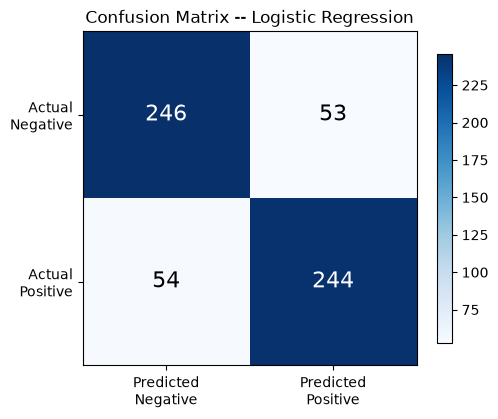

In [23]:
# close=False so Jupyter can draw the figure before it is closed.
evaluate.plot_confusion_matrix(
    y_test, predictions["Logistic Regression"],
    title="Confusion Matrix -- Logistic Regression",
    close=False,
)
plt.show()

### Why accuracy alone is not enough

A concrete demonstration on our own test set: what would a model that simply always
answers "Positive" score?

In [24]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(x_train, y_train)
dummy_metrics = evaluate.compute_metrics(y_test, dummy.predict(x_test))
print(f"always-majority baseline : accuracy {dummy_metrics['accuracy']:.4f}, "
      f"F1-macro {dummy_metrics['f1_macro']:.4f}")

lr_metrics = evaluate.compute_metrics(y_test, predictions["Logistic Regression"])
print(f"our model                : accuracy {lr_metrics['accuracy']:.4f}, "
      f"F1-macro {lr_metrics['f1_macro']:.4f}")

print("\nOur data is balanced, so the baseline scores ~50% and beating it clearly")
print("means real learning. Now imagine the data were 95% positive: that same")
print("useless baseline would score 95% accuracy -- while its F1-macro stayed")
print("terrible. THAT is why we never report accuracy on its own.")

always-majority baseline : accuracy 0.5008, F1-macro 0.3337
our model                : accuracy 0.8208, F1-macro 0.8208

Our data is balanced, so the baseline scores ~50% and beating it clearly
means real learning. Now imagine the data were 95% positive: that same
useless baseline would score 95% accuracy -- while its F1-macro stayed
terrible. THAT is why we never report accuracy on its own.


## 7. What did the model actually learn?

Logistic Regression keeps one weight per feature, so we can simply read it.

In [25]:
logreg_model = models["Logistic Regression"]
top_positive, top_negative = features.top_features_for_class(
    vectorizer, logreg_model, n=15)

print(pd.DataFrame({
    "positive term": [t for t, _ in top_positive],
    "weight  ": [round(w, 2) for _, w in top_positive],
    "negative term": [t for t, _ in top_negative],
    "weight": [round(w, 2) for _, w in top_negative],
}).to_string(index=False))

positive term  weight    negative term  weight
        great     10.49            not   -9.33
         good      8.14            bad   -7.43
         love      5.12           poor   -5.14
         nice      5.11       terrible   -4.78
      amazing      4.98          worst   -4.69
    excellent      4.83            don   -4.26
          and      4.53 disappointment   -3.59
    delicious      4.28         stupid   -3.48
    wonderful      4.24       not good   -3.45
         well      4.17          awful   -3.40
      awesome      4.02           then   -3.36
         best      3.97      the worst   -3.32
     the best      3.96  disappointing   -3.24
        works      3.90        minutes   -3.23
    beautiful      3.69   disappointed   -3.01


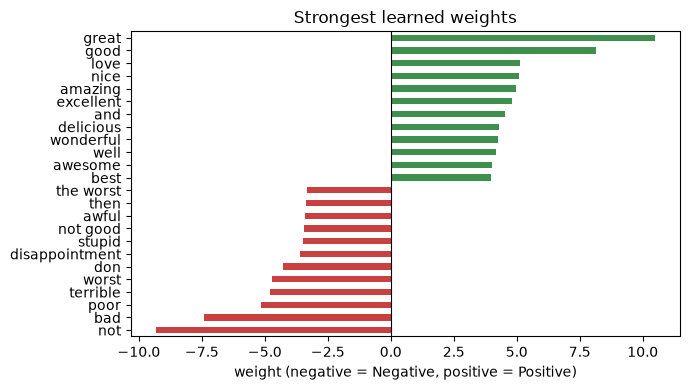

In [26]:
weights = pd.Series(logreg_model.coef_[0], index=vocab)
chart = pd.concat([weights.nlargest(12), weights.nsmallest(12)]).sort_values()

ax = chart.plot(kind="barh",
                color=["#c94040" if w < 0 else "#3f8f4f" for w in chart])
ax.set_title("Strongest learned weights")
ax.set_xlabel("weight (negative = Negative, positive = Positive)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Did the bigrams do their job?

This is the direct test of the `ngram_range=(1, 2)` decision. If the model learned a
*different* weight for a negated phrase than for the word alone, bigrams earned their
place.

In [27]:
pairs = [("good", "not good"), ("great", "not great"), ("like", "not like"),
         ("worth", "not worth"), ("recommend", "not recommend")]

rows = []
for word, phrase in pairs:
    if word in weights.index and phrase in weights.index:
        rows.append({"unigram": word, "weight": round(weights[word], 2),
                     "bigram": phrase, "bigram weight": round(weights[phrase], 2)})

print(pd.DataFrame(rows).to_string(index=False))
print("\n-> the model learned that the negated phrase means something different")
print("   from the word alone. That is exactly why we included bigrams.")

  unigram  weight        bigram  bigram weight
     good    8.14      not good          -3.45
    great   10.49     not great          -0.26
     like   -0.04      not like          -0.36
    worth    0.96     not worth          -1.62
recommend    2.95 not recommend          -0.92

-> the model learned that the negated phrase means something different
   from the word alone. That is exactly why we included bigrams.


### A weight that should make you suspicious

Reading the weights is not just a party trick — it is how you catch problems that
accuracy hides.

In [28]:
for term in ["and", "the", "was", "but", "then", "minutes"]:
    if term in weights.index:
        print(f"  {term:10} {weights[term]:+.2f}")

print("\n'and' has no sentiment, yet it carries a large positive weight.")
print("In this corpus, positive sentences happen to string clauses together")
print("('good value and fast delivery'), so the correlation is genuinely in the")
print("training data -- but it is a quirk of 2,385 sentences, not a fact about")
print("English. This is concrete evidence of overfitting a small corpus, and it")
print("is the kind of thing you only find by LOOKING at the model.")

  and        +4.53
  the        -0.40
  was        -1.94
  but        -0.05
  then       -3.36
  minutes    -3.23

'and' has no sentiment, yet it carries a large positive weight.
In this corpus, positive sentences happen to string clauses together
('good value and fast delivery'), so the correlation is genuinely in the
training data -- but it is a quirk of 2,385 sentences, not a fact about
English. This is concrete evidence of overfitting a small corpus, and it
is the kind of thing you only find by LOOKING at the model.


## 8. Error analysis — the 100-odd reviews it got wrong

More useful than another hyperparameter sweep. Let us read the mistakes.

In [29]:
y_pred_lr = predictions["Logistic Regression"]
y_proba_lr = logreg_model.predict_proba(x_test)[:, 1]

errors = pd.DataFrame({
    "review": df.loc[x_test_text.index, config.TEXT_COLUMN],
    "actual": [config.LABEL_NAMES[v] for v in y_test],
    "predicted": [config.LABEL_NAMES[v] for v in y_pred_lr],
    "p_positive": y_proba_lr.round(3),
})
errors = errors[errors["actual"] != errors["predicted"]]

print(f"{len(errors)} mistakes out of {len(y_test)} test reviews "
      f"({len(errors) / len(y_test):.1%})\n")
print(errors["actual"].value_counts().to_string())

107 mistakes out of 597 test reviews (17.9%)

actual
Positive    54
Negative    53


In [30]:
# The most confident mistakes -- these are the most informative ones to read.
errors["confidence"] = np.where(errors["predicted"] == "Positive",
                                errors["p_positive"], 1 - errors["p_positive"])
worst = errors.nlargest(8, "confidence")

for _, row in worst.iterrows():
    print(f"[actual {row['actual']}, predicted {row['predicted']} "
          f"at {row['confidence']:.0%} confidence]")
    print(f"  {row['review'][:150]}\n")

[actual Positive, predicted Negative at 98% confidence]
  The soundtrack wasn't terrible, either.

[actual Positive, predicted Negative at 92% confidence]
  I went to Bachi Burger on a friend's recommendation and was not disappointed.

[actual Positive, predicted Negative at 92% confidence]
  I usually don't like headbands but this one is very lightweight & doesn't mess up my hair.

[actual Positive, predicted Negative at 91% confidence]
  Waste your money on this game.

[actual Positive, predicted Negative at 91% confidence]
  This is the kind of money that is wasted properly.

[actual Positive, predicted Negative at 90% confidence]
  A film not easily forgotten.

[actual Positive, predicted Negative at 89% confidence]
  You get extra minutes so that you can carry out the call and not get cut off."

[actual Positive, predicted Negative at 88% confidence]
  I would have casted her in that role after ready the script.



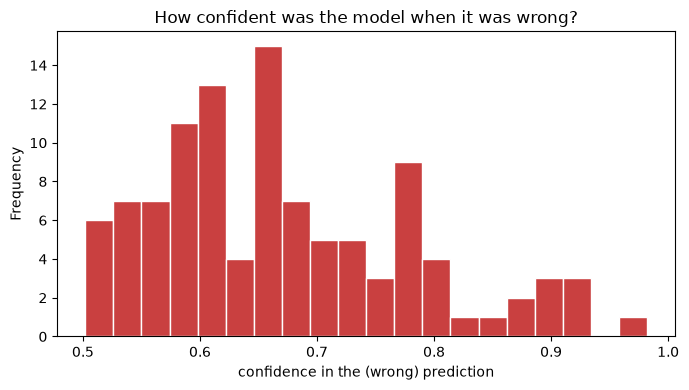

mistakes made at under 70% confidence: 66%

A large share of borderline errors is good news: it means a confidence
threshold could route the uncertain cases to a human instead of guessing.


In [31]:
# Are the mistakes mostly borderline cases, or confident errors?
ax = errors["confidence"].plot(kind="hist", bins=20, color="#c94040",
                               edgecolor="white")
ax.set_title("How confident was the model when it was wrong?")
ax.set_xlabel("confidence in the (wrong) prediction")
plt.tight_layout()
plt.show()

print(f"mistakes made at under 70% confidence: "
      f"{(errors['confidence'] < 0.7).mean():.0%}")
print("\nA large share of borderline errors is good news: it means a confidence")
print("threshold could route the uncertain cases to a human instead of guessing.")

## 9. Conclusions

**What the experiments established** (all on cross-validation, training set only):

| Decision | Chosen | Because |
| --- | --- | --- |
| `C` | 10 | smallest value on the accuracy plateau |
| `min_df` | 1 | dropping once-seen words costs ~1 point on a corpus this small |
| `ngram_range` | (1, 2) | bigrams help; trigrams add features for nothing |
| `sublinear_tf` | off | nothing to dampen in single-sentence reviews |

**Final measured performance** on 597 reviews the model never saw: roughly **82%
accuracy**, with precision and recall both around 0.82 and ROC-AUC near 0.90.
Logistic Regression edged out Naive Bayes by about a point — close enough that the
honest summary is "slightly ahead, and more interpretable".

**What limits it:** the dataset is small and the reviews are single sentences; there is
no neutral class; sarcasm is impossible for a bag-of-words model; and the `and` weight
shows some corpus quirks were learned. More and longer data is the highest-value next
step — not a fancier model.

To reproduce the saved artifacts from the command line:

```
python -m src.train
```